In [46]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import logging
from patsy import bs
import itertools

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [47]:
# Configuration

MODE = 'bdiff'

if MODE == '06':
    base_path = Path('firemen/firepoint/2x2/test/occurence_062023/all/full_all_3_0_zonemeteo_node/')
    parent_dir_name = 'full_all_3_0_zonemeteo_node/'
    path_baseline = Path('06/')
elif MODE == 'bdiff':
    base_path = Path('bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/')
    path_baseline = Path('bdiff/')
elif MODE == 'firemen':
    pass

scale = 10
horizon = 0

clustering = 'kmeans'

models = [
    'GRU_search_full_10_0_all_one_',
]

losses = [
    'regression_pdegpd',
    'classification_flwki-id{departement}',
    'classification_flwk',
    'classification_weightedcrossentropy',
    'classification_wkloss',
    'classification_bceloss',
    'classification_fl',
    'regression_cll',
]

targets = [
   f'nbsinister-{clustering}-5-Class-Dept',
   f'burnedareaRoot-{clustering}-5-Class-Dept',
]

all_dir = list(itertools.product(models, losses, targets))

loss_2 = ["regression_ccllt-id{node}-nclusters{95}"]
targets_2 = ["nbsinister", "burnedareaRoot"]

all_dir_2 = list(itertools.product(models, loss_2, targets_2))

all_dir = all_dir + all_dir_2

In [ ]:
import os
import io
import pandas as pd
import paramiko

def list_remote_pkl_files(sftp, remote_dir):
    pkl_files = []

    # 1) essayer remote_dir/H0/*.pkl
    h0_dir = remote_dir.rstrip("/") + "/H0"
    try:
        for f in sftp.listdir(h0_dir):
            if f.endswith(".pkl"):
                pkl_files.append(h0_dir + "/" + f)
    except FileNotFoundError:
        pass

    # 2) sinon remote_dir/*.pkl
    if not pkl_files:
        try:
            for f in sftp.listdir(remote_dir):
                if f.endswith(".pkl"):
                    pkl_files.append(remote_dir.rstrip("/") + "/" + f)
        except FileNotFoundError:
            pass

    return pkl_files

def read_remote_pickle(sftp, remote_file_path):
    # Lire le fichier distant dans un buffer mémoire puis le donner à pandas
    with sftp.open(remote_file_path, "rb") as f:
        data = f.read()
    return pd.read_pickle(io.BytesIO(data))

def find_remote_directories(sftp, base_path_remote, all_dir):
    matches = []

    # Vérifie que base_path_remote existe
    try:
        sftp.listdir(base_path_remote)
    except FileNotFoundError:
        print(f"Base path does not exist on remote: {base_path_remote}")
        return []

    for (model, loss, target) in all_dir:
        print(model, loss, target)
        dir_name = f"{model}{target}_{loss}"
        full_path = base_path_remote.rstrip("/") + "/" + dir_name
        print(full_path)
        try:
            # Si listdir marche, c'est un dossier existant
            sftp.listdir(full_path)
            matches.append((full_path, model, loss, target))
        except FileNotFoundError:
            continue

    return matches

TARGET_MAP = {
    "nbsinister-kmeans-5-Class-Dept": "nbsinister",
    "burnedareRoot-kmeans-5-Class-Dept": "burnedareaRoot",
}

_INV_CLLT_TARGET_MAP = {v: k for k, v in TARGET_MAP.items()}

# --- Connexion SSH ---
hostname = "mesohelios1.univ-fcomte.fr"
username = "ncaron"
password = "xp2nrfeu"
#key_path = "/chemin/vers/id_rsa"  # si clé

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
ssh.connect(hostname, username=username, password=password)

sftp = ssh.open_sftp()

# --- Utilisation ---
base_path_remote = (Path("/Home/Users/ncaron/WORK/GNN") / base_path).as_posix()
directories = find_remote_directories(sftp, base_path_remote, all_dir)
print(f"Found {len(directories)} directories matching configuration.")

all_data_frames = {}
gt_dfs = {}
target_cols = {}

for d, model, loss, target in directories:

    if target not in all_data_frames.keys():
        if target in ["burnedareaRoot", "nbsinister"]:
            if _INV_CLLT_TARGET_MAP[target] not in all_data_frames.keys():
                all_data_frames[_INV_CLLT_TARGET_MAP[target]] =  {}
        else:
            all_data_frames[target] = {}

    if target is None:
        continue
    
    pkl_files = list_remote_pkl_files(sftp, d)
    if not pkl_files:
        continue

    file_path = pkl_files[0]

    try:
        res = read_remote_pickle(sftp, file_path)
    except Exception as e:
        print(f"Error loading {d}: {e}")
        continue

    if "date" not in res.columns or "graph_id" not in res.columns:
        print(f"Skipping {d}: missing date or graph_id")
        continue

    if target in ["burnedareaRoot", "nbsinister"]:
        target = _INV_CLLT_TARGET_MAP[target]

    pred_col = f"prediction_{target}_0"

    if 'ccllt' in loss:
        pred_col = pred_col.replace("kmeans", "quantile")        

    if pred_col not in res.columns:
        if target in res.columns:
            pred_col = target
        else:
            print(f"Skipping {d}: no prediction column")
            continue

    df = res[["date", "departement", "graph_id", target]].copy()
    df["risk_score"] = res[pred_col]
    df[pred_col] = res[pred_col]
    df["config"] = f"{model}{loss}"

    if "nbsinister" in target:
        df["nbsinister"] = res["nbsinister"]
    else:
        df["burnedareaRoot"] = res["burnedareaRoot"]

    df["num_zone"] = df["graph_id"]
    all_data_frames[target][f"{model}{loss}"] = df

    baseline_col = f"{target}"
    has_baseline = baseline_col in res.columns

    cols_to_keep = ["date", "departement", "graph_id", "nbsinister", "burnedareaRoot"]
    if has_baseline:
        cols_to_keep.append(baseline_col)

    gt_df = res[cols_to_keep].copy()
    gt_df["num_zone"] = gt_df["graph_id"]
    gt_dfs[target] = gt_df
    target_cols[target] = target
    
"""print(f"Loaded {len(data_frames)} configurations.")
if data_frames:
    risk_all = pd.concat(data_frames.values(), ignore_index=True)
    print("risk_all shape:", risk_all.shape)"""

sftp.close()
ssh.close()

INFO:paramiko.transport:Connected (version 2.0, client OpenSSH_8.0)
INFO:paramiko.transport:Authentication (publickey) failed.
INFO:paramiko.transport:Authentication (publickey) failed.
INFO:paramiko.transport:Authentication (password) successful!
INFO:paramiko.transport.sftp:[chan 0] Opened sftp connection (server version 3)


GRU_search_full_10_0_all_one_ regression_pdegpd nbsinister-kmeans-5-Class-Dept
/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_regression_pdegpd
GRU_search_full_10_0_all_one_ regression_pdegpd burnedareaRoot-kmeans-5-Class-Dept
/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/GRU_search_full_10_0_all_one_burnedareaRoot-kmeans-5-Class-Dept_regression_pdegpd
GRU_search_full_10_0_all_one_ classification_flwki-id{departement} nbsinister-kmeans-5-Class-Dept
/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_flwki-id{departement}
GRU_search_full_10_0_all_one_ classification_flwki-id{departement} burnedareaRoot-kmeans-5-Class-Dept
/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occu

In [ ]:
all_data_frames

{'nbsinister-kmeans-5-Class-Dept': {'GRU_search_full_10_0_all_one_regression_pdegpd':        date  departement  graph_id  nbsinister-kmeans-5-Class-Dept  \
  0      2029            1       0.0                               0   
  1      2030            1       0.0                               0   
  2      2031            1       0.0                               0   
  3      2032            1       0.0                               0   
  4      2033            1       0.0                               0   
  ...     ...          ...       ...                             ...   
  33483  2388           95      93.0                               0   
  33484  2389           95      93.0                               0   
  33485  2390           95      93.0                               0   
  33486  2391           95      93.0                               0   
  33487  2392           95      93.0                               0   
  
         risk_score  prediction_nbsinister-kmeans

In [ ]:
all_data_frames['nbsinister-kmeans-5-Class-Dept'].keys()

dict_keys(['GRU_search_full_10_0_all_one_regression_pdegpd', 'GRU_search_full_10_0_all_one_classification_flwki-id{departement}', 'GRU_search_full_10_0_all_one_classification_flwk', 'GRU_search_full_10_0_all_one_classification_weightedcrossentropy', 'GRU_search_full_10_0_all_one_classification_wkloss', 'GRU_search_full_10_0_all_one_classification_bceloss', 'GRU_search_full_10_0_all_one_regression_ccllt-id{node}-nclusters{95}'])

In [ ]:
target_cols

{'nbsinister-kmeans-5-Class-Dept': 'nbsinister-kmeans-5-Class-Dept',
 'burnedareaRoot-kmeans-5-Class-Dept': 'burnedareaRoot-kmeans-5-Class-Dept'}

In [ ]:
import sys, pickle
from pathlib import Path

# Ensure GNN subdir is on the path so pickle can find forecasting_models classes
_gnn_path = str(Path('GNN').resolve())
if _gnn_path not in sys.path:
    sys.path.insert(0, _gnn_path)

# Load scorers — one per target, stored in path_baseline as scorer_<SimpleName>.pkl
_SCORER_NAMES = {
    "nbsinister": "Fire",
    "burnedareaRoot": "BurnedArea",
}

scorers = {}
for _target, _simple in _SCORER_NAMES.items():
    _scorer_path = path_baseline / f"scorer_{_simple}.pkl"
    if _scorer_path.exists():
        with open(_scorer_path, 'rb') as _f:
            scorers[_simple] = pickle.load(_f)
        print(f"Loaded scorer for '{_simple}' from {_scorer_path}")
    else:
        print(f"WARNING: scorer file not found: {_scorer_path}")

print(f"Scorers loaded: {list(scorers.keys())}")

Loaded scorer for 'Fire' from bdiff/scorer_Fire.pkl
Loaded scorer for 'BurnedArea' from bdiff/scorer_BurnedArea.pkl
Scorers loaded: ['Fire', 'BurnedArea']


In [ ]:
key = list(all_data_frames['nbsinister-kmeans-5-Class-Dept'].keys())[0]
depts = np.sort(all_data_frames['nbsinister-kmeans-5-Class-Dept'][key]['departement'].unique())

In [ ]:
scorers['Fire'].pair_mean_deltas

{(0, 1): 2.6279656506423876,
 (1, 2): 2.8215566048741394,
 (2, 3): 3.9084656828110553,
 (3, 4): 7.664776921069635,
 (0, 2): 5.449522255516527,
 (1, 3): 6.730022287685195,
 (2, 4): 11.57324260388069,
 (0, 3): 9.357987938327582,
 (1, 4): 14.39479920875483,
 (0, 4): 17.022764859397217}

In [ ]:
import datetime as dt, numpy as np, pandas as pd
from sklearn.metrics import recall_score

def find_dates_between(start, end):
    import datetime as _dt
    d = _dt.datetime.strptime(start,'%Y-%m-%d').date()
    e = _dt.datetime.strptime(end,'%Y-%m-%d').date()
    res = []
    while d < e:
        res.append(d.strftime('%Y-%m-%d')); d += _dt.timedelta(days=1)
    return res

allDates = find_dates_between('2017-06-12', '2024-12-31')

all_target_results = {}
TARGETS      = ["nbsinister"]
SIMPLE_NAMES = {"nbsinister": "Fire"}

dfe_results_all = []
fwi_results_all = []

def _score(df, pred_col, target_col, sc):
    try:
        sh, sl, cov, adj, smc, _, _ = sc.evaluation_scoring(
            df[pred_col].astype(float), df[target_col].fillna(0),
            df['date'], df['num_zone'],
            df_spline=5, min_n=1, reference=False
        )
        rec = recall_score(df[target_col] > 0, df[pred_col] > 0, zero_division=0)
        return {
            'score_high': sh, 'score_low': sl, 'score_min_class': smc, 'recall': rec,
            **{f'score_k{k}': float(adj.get(k, float('nan'))) for k in [1,2,3,4]},
            **{f'coverage_k{k}': int(cov.get(k, 0)) for k in [1,2,3,4]},
        }
    except Exception as e:
        print(f"    Scoring error: {e}"); return None

def _fill(row, prefix, r):
    if r:
        for k in [1,2,3,4]:
            row[f'{prefix}SCORE_k{k}'] = r.get(f'score_k{k}', float('nan'))
        for key in ['score_high','score_low','score_min_class','recall']:
            row[f'{prefix}{key.upper()}'] = r.get(key, float('nan'))
    else:
        for k in [1,2,3,4]:
            row[f'{prefix}SCORE_k{k}'] = float('nan')
        for key in ['score_high','score_low','score_min_class','recall']:
            row[f'{prefix}{key.upper()}'] = float('nan')

def _compute_agg(curr_metrics, ref_metrics):
    if not curr_metrics or not ref_metrics: return float('nan')
    EPS = 1e-6
    u_vals = []
    keys = [f'score_k{k}' for k in [1,2,3,4]] + ['recall', 'score_min_class']
    for k in keys:
        sk = float(curr_metrics.get(k, 0))
        skr = float(ref_metrics.get(k, 0))
        denom = max(abs(skr) + EPS, 0.1)
        u = (np.tanh((sk - skr) / denom) + 1.0) / 2.0
        u_vals.append(max(u, EPS))
    U = np.exp(np.mean(np.log(u_vals)))
    return float(2.0 * U - 1.0)

def load_baseline_metrics(target_name, mode='fwi', dept_id=None):
    fname = f"{mode}_scores_{target_name}.csv"
    try:
        bdf = pd.read_csv(path_baseline / fname)
        if dept_id is not None:
             # Logic to filter by department if baseline CSV has it
             # For now we useDataset column as '2023' (global) as fallback
            row = bdf[bdf['Dataset'] == f'2023_{dept_id}']
        else:
             row = bdf[bdf['Dataset'] == '2023']
        if row.empty: return None
        data = row.iloc[0]
        res = {f'score_k{k}': data.get(f'k{k}', 0) for k in [1,2,3,4]}
        res['recall'] = data.get('recall', 0)
        res['score_min_class'] = data.get('min_class_score', 0)
        return res
    except: return None

print("Starting dual scoring (FWI 2023 / DFE 2023 summer) with per-department AGG scores...")

for target_key in TARGETS:
    matched_key = _INV_CLLT_TARGET_MAP[target_key]
    if matched_key not in all_data_frames.keys():
        print(f"Target {target_key} not found in all_data_frames"); continue

    simple_name = SIMPLE_NAMES[target_key]
    sc = scorers.get(simple_name)
    if sc is None:
        print(f"No scorer for {simple_name}  — skipping"); continue

    print(f"\n{'='*40}\n{simple_name} (sigma={sc.sigma:.4f})\n{'='*40}")
    ref_fwi_global = load_baseline_metrics(simple_name, 'fwi')
    ref_dfe_6      = load_baseline_metrics(simple_name, 'dfe')

    models_dict = all_data_frames[matched_key]
    gt_df_orig  = gt_dfs[matched_key].copy()
    gt_df_orig['date'] = gt_df_orig['date'].apply(lambda x: allDates[int(x)] if int(x)<len(allDates) else allDates[-1])
    gt_df_orig['date'] = pd.to_datetime(gt_df_orig['date'])
    gt_df_orig['num_zone'] = gt_df_orig['num_zone'].astype(int)

    results_list = []
    for model_name, df_pred in models_dict.items():

        df_p = df_pred.copy()
        df_p['date'] = df_p['date'].apply(lambda x: allDates[int(x)] if int(x)<len(allDates) else allDates[-1])
        df_p['date'] = pd.to_datetime(df_p['date'])
        df_p['num_zone'] = df_p['num_zone'].astype(int)

        gt_temp = gt_df_orig[['date','num_zone', target_key]].copy()
        merged  = pd.merge(df_p, gt_temp, on=['date','num_zone'], how='inner', suffixes=('','_gt'))
        merged = merged[merged['date'].dt.year == 2023]
        if merged.empty:
            print(f"  [{model_name}] empty merge for 2023 — skipped"); continue

        row_combined = {'Model': model_name, 'Target': simple_name}
        r_fwi_global = _score(merged, 'risk_score', target_key, sc)
        _fill(row_combined, 'FWI_Global_', r_fwi_global)
        row_combined['AGG_FWI_Global'] = _compute_agg(r_fwi_global, ref_fwi_global)
        
        all_depts = np.sort(merged['departement'].unique())
        for d_id in all_depts:
            m_dept = merged[merged['departement'] == d_id]
            r_fwi_d = _score(m_dept, 'risk_score', target_key, sc)
            ref_fwi_d = load_baseline_metrics(simple_name, 'fwi', d_id)
            _fill(row_combined, f'FWI_{int(d_id)}_', r_fwi_d)
            # Compute AGG per dept using global baseline as reference (or per-dept baseline if available later)
            row_combined[f'AGG_FWI_{int(d_id)}'] = _compute_agg(r_fwi_d, ref_fwi_d)

        dts = merged['date'].dt
        dept_mask = merged['departement'] == 6
        summer_mask = ((dts.month > 6) | ((dts.month == 6) & (dts.day >= 15))) & \
                      ((dts.month < 9) | ((dts.month == 9) & (dts.day <= 25)))

        merged_dfe = merged[summer_mask & dept_mask]
        r_dfe = _score(merged_dfe, 'risk_score', target_key, sc) if not merged_dfe.empty else None
        _fill(row_combined, 'DFE_6_', r_dfe)
        row_combined['AGG_DFE_6'] = _compute_agg(r_dfe, ref_dfe_6)
        
        fwi_results_all.append(row_combined.copy())
        if r_dfe:
            row_dfe = {'Model': model_name, 'Target': simple_name, 'AGG': row_combined['AGG_DFE_6']}
            row_dfe.update(r_dfe)
            dfe_results_all.append(row_dfe)
        results_list.append(row_combined)
        
    if results_list:
        df_res = pd.DataFrame(results_list).set_index('Model')
        all_target_results[simple_name] = {'scores_lh_plot': df_res}
        agg_cols = [c for c in df_res.columns if 'AGG' in c]
        print(df_res[agg_cols].head())

# Save outputs
if dfe_results_all:
    pd.DataFrame(dfe_results_all).to_csv('results_dfe_2023_v2.csv', index=False)
    print(f"\n Saved results_dfe_2023_v2.csv ({len(dfe_results_all)} rows)")
if fwi_results_all:
    pd.DataFrame(fwi_results_all).to_csv('results_fwi_2023_v2.csv', index=False)
    print(f" Saved results_fwi_2023_v2.csv ({len(fwi_results_all)} rows)")
print("\nDone.")


Starting dual scoring (FWI 2023 / DFE 2023 summer) with per-department AGG scores...

Fire (sigma=0.3795)
                                                    AGG_FWI_Global  AGG_FWI_1  \
Model                                                                           
GRU_search_full_10_0_all_one_regression_pdegpd            0.657407   0.122462   
GRU_search_full_10_0_all_one_classification_flw...        0.583284   0.122462   
GRU_search_full_10_0_all_one_classification_flwk          0.153806   0.122462   
GRU_search_full_10_0_all_one_classification_wei...       -0.921628   0.122462   
GRU_search_full_10_0_all_one_classification_wkloss       -0.143929   0.122462   

                                                    AGG_FWI_2  AGG_FWI_3  \
Model                                                                      
GRU_search_full_10_0_all_one_regression_pdegpd       0.122462   0.122462   
GRU_search_full_10_0_all_one_classification_flw...   0.122462   0.122462   
GRU_search_full_10_0_a

In [ ]:
# --- Per-Target comparison tables: Models vs FWI Baseline (2023, dept from MODE) ---
import pandas as pd
import numpy as np

# Département extrait depuis MODE ('06' -> 6)

dept = list(depts) + ['Global'] 

all_dept_tables = []

for d in dept:

    if d == 'Global':
        BASELINE_DATASET_KEY = f"2023"
    else:
        BASELINE_DATASET_KEY = f"2023_{d}"

    def load_fwi_baseline(target_name):
        """
        Load FWI baseline for target_name from path_baseline/fwi_scores_{target_name}.csv.
        Uses row Dataset == '2023_{DEPT}', fallback to 'Global'.
        Returns dict with score_k1..4, recall, score_min_class or None.
        """
        fname = path_baseline / f"fwi_scores_{target_name}.csv"
        try:
            bdf = pd.read_csv(fname)
        except FileNotFoundError:
            print(f"  baseline file not found: {fname}")
            return None

        row = bdf[bdf['Dataset'] == BASELINE_DATASET_KEY]
        if row.empty:
            row = bdf[bdf['Dataset'] == 'Global']
            if not row.empty:
                print(f"  [{target_name}] no row for {BASELINE_DATASET_KEY!r}, using 'Global'")
        if row.empty:
            print(f"  [{target_name}] no baseline row found (tried {BASELINE_DATASET_KEY!r} and 'Global')")
            return None

        data = row.iloc[0]
        return {
            'score_k1':       float(data.get('k1', np.nan)),
            'score_k2':       float(data.get('k2', np.nan)),
            'score_k3':       float(data.get('k3', np.nan)),
            'score_k4':       float(data.get('k4', np.nan)),
            'recall':         float(data.get('recall', np.nan)),
            'score_min_class': float(data.get('score_min_class', np.nan)),
        }

    def get_val(row, *candidates):
        for c in candidates:
            if c in row.index and pd.notna(row[c]):
                return float(row[c])
        return np.nan

    DISPLAY_COLS = [
        ('score_k1',        'k1'),
        ('score_k2',        'k2'),
        ('score_k3',        'k3'),
        ('score_k4',        'k4'),
        ('recall',          'recall'),
        ('score_min_class', 'min_class'),
        ('agg',             'AGG'),
    ]


    for target in ['Fire']:
        if target not in all_target_results:
            print(f"[{target}] not in all_target_results — skipping.")
            continue

        scores_lh = all_target_results[target].get('scores_lh_plot', pd.DataFrame())
        if scores_lh.empty:
            print(f"[{target}] scores_lh_plot empty — skipping.")
            continue

        ref = load_fwi_baseline(target)
        rows = []

        # --- Baseline row ---
        if ref:
            base_row = {'Model': f'Baseline FWI ({BASELINE_DATASET_KEY})'}
            for sk, label in DISPLAY_COLS:
                if sk == 'agg':
                    base_row[label] = np.nan
                else:
                    base_row[label] = ref.get(sk, np.nan)
            rows.append(base_row)
        else:
            print(f"  [{target}] baseline not loaded.")

        # --- Model rows ---
        for model_name, row in scores_lh.iterrows():
            model_row = {'Model': model_name}
            for sk, label in DISPLAY_COLS:
                if sk == 'agg':
                    val = get_val(row, f'AGG_FWI_{d}')
                elif sk == 'recall':
                    val = get_val(row, f'FWI_{d}_RECALL', 'RECALL')
                elif sk == 'score_min_class':
                    val = get_val(row, f'FWI_{d}_SCORE_MIN_CLASS', 'SCORE_MIN_CLASS')
                else:
                    k = sk[-1]
                    val = get_val(row,
                        f'FWI_{d}_SCORE_k{k}',
                        f'SCORE_k{k}',
                    )
                model_row[label] = val
            rows.append(model_row)

        df_table = pd.DataFrame(rows).set_index('Model')

        print(f"\n{'═'*65}")
        print(f"  {target}  —  baseline: {BASELINE_DATASET_KEY}")
        print(f"{'═'*65}")
        print(df_table.to_markdown(floatfmt=".4f"))
        print()

    if d != 'Global':
        all_dept_tables.append(df_table)

# --- Print Average Table ---
if all_dept_tables:
    df_avg = pd.concat(all_dept_tables).groupby('Model').mean()
    # Sort to keep the baseline at the top if it's there
    baseline_index = [i for i in df_avg.index if 'Baseline' in i]
    other_index = [i for i in df_avg.index if 'Baseline' not in i]
    df_avg = df_avg.reindex(baseline_index + other_index)
    
    print(f"\n{'═'*65}")
    print(f"  Fire  —  Average (Depts: 6, 13, 34, 83)")
    print(f"{'═'*65}")
    print(df_avg.to_markdown(floatfmt=".4f"))
    print()



═════════════════════════════════════════════════════════════════
  Fire  —  baseline: 2023_1
═════════════════════════════════════════════════════════════════
| Model                                                                |     k1 |     k2 |     k3 |     k4 |   recall |   min_class |      AGG |
|:---------------------------------------------------------------------|-------:|-------:|-------:|-------:|---------:|------------:|---------:|
| Baseline FWI (2023_1)                                                | 0.0000 | 0.0000 | 0.0000 | 0.0000 |   0.0000 |      1.0000 | nan      |
| GRU_search_full_10_0_all_one_regression_pdegpd                       | 0.0000 | 0.0000 | 0.0000 | 0.0000 |   0.0000 |      1.0000 |   0.1225 |
| GRU_search_full_10_0_all_one_classification_flwki-id{departement}    | 0.0000 | 0.0000 | 0.0000 | 0.0000 |   0.0000 |      1.0000 |   0.1225 |
| GRU_search_full_10_0_all_one_classification_flwk                     | 0.0000 | 0.0000 | 0.0000 | 0.0000 |   0.0


  VISUALIZING TOP-2 MODELS FOR: Fire (sorted by AGG_DFE_6)

>>> Plotting Fit for GRU_search_full_10_0_all_one_regression_ccllt-id{node}-nclusters{95} (AGG: -0.2337)


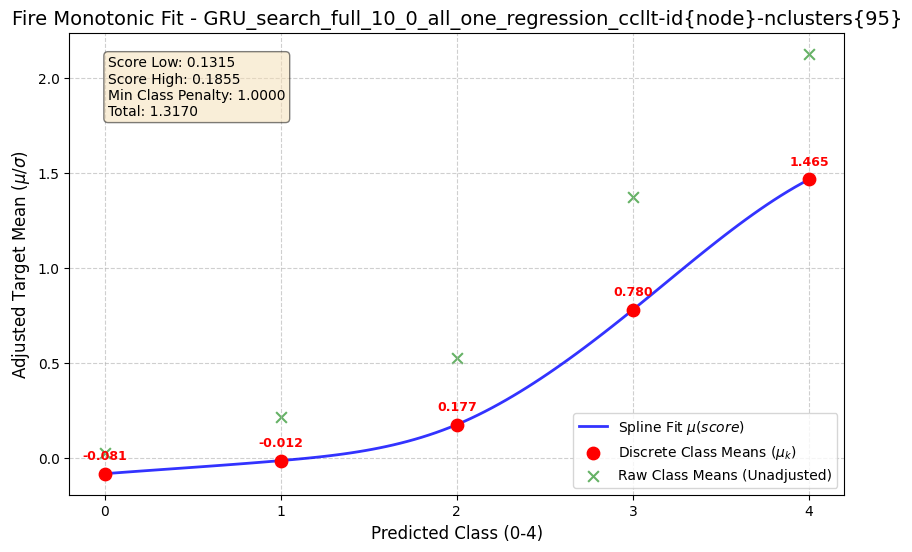


>>> Plotting Fit for GRU_search_full_10_0_all_one_regression_pdegpd (AGG: -0.2343)


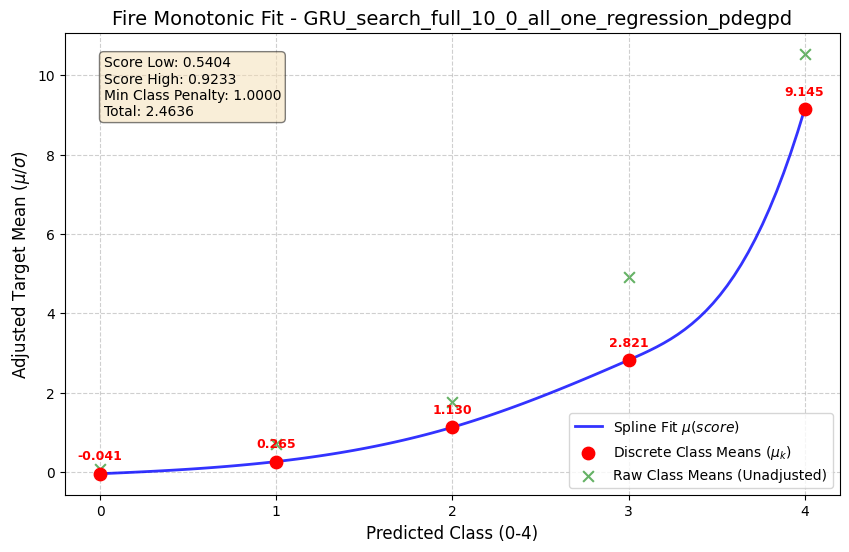

In [ ]:
# --- Visualization: Top-2 Models by AGG score per Target ---
import pandas as pd
import matplotlib.pyplot as plt

# We iterate over the simple names used in all_target_results
for simple_name in ['Fire']:
    if simple_name not in all_target_results:
        print(f"[{simple_name}] not found in all_target_results — skipping visualization.")
        continue
    
    res = all_target_results[simple_name]
    df_res = res.get('scores_lh_plot', pd.DataFrame())
    if df_res.empty: continue
    
    # Selection of top 2 models by AGG
    agg_candidates = [c for c in df_res.columns if 'AGG' in c]
    if not agg_candidates: continue
    
    agg_col = 'AGG_DFE_6' if 'AGG_DFE_6' in df_res.columns else agg_candidates[0]
    
    # Identify top 2 models
    top_models = df_res.sort_values(agg_col, ascending=False).head(2)
    
    print(f"\n{'='*70}\n  VISUALIZING TOP-2 MODELS FOR: {simple_name} (sorted by {agg_col})\n{'='*70}")
    
    sc = scorers.get(simple_name)
    if sc is None:
        print(f"Scorer not found for {simple_name}"); continue
    
    # Find the short_key from SIMPLE_NAMES inverse
    short_key = None
    for k, v in SIMPLE_NAMES.items():
        if v == simple_name:
            short_key = k
            break
    
    # Use _INV_CLLT_TARGET_MAP to get target_key (long name)
    target_key = _INV_CLLT_TARGET_MAP.get(short_key)
    if target_key is None or target_key not in gt_dfs:
        print(f"Ground truth link not found for {simple_name} (short_key: {short_key})"); continue

    gt_df_orig = gt_dfs[target_key].copy()
    gt_df_orig['date'] = gt_df_orig['date'].apply(lambda x: allDates[int(x)] if int(x)<len(allDates) else allDates[-1])
    gt_df_orig['date'] = pd.to_datetime(gt_df_orig['date'])
    gt_df_orig['num_zone'] = gt_df_orig['num_zone'].astype(int)

    for model_name, row in top_models.iterrows():
        print(f"\n>>> Plotting Fit for {model_name} (AGG: {row[agg_col]:.4f})")
        
        # Get predictions
        models_dict = all_data_frames.get(target_key, {})
        df_pred = models_dict.get(model_name)
        if df_pred is None:
            print(f"  Predictions not found for {model_name}"); continue
        
        df_p = df_pred.copy()
        df_p['date'] = df_p['date'].apply(lambda x: allDates[int(x)] if int(x)<len(allDates) else allDates[-1])
        df_p['date'] = pd.to_datetime(df_p['date'])
        df_p['num_zone'] = df_p['num_zone'].astype(int)

        # Merge for scoring. Use suffixes to avoid renaming the model's prediction columns.
        # We need the ground truth from gt_df_orig, so we take it from the '_gt' columns.
        merged = pd.merge(df_p, gt_df_orig, on=['date', 'num_zone'], how='inner', suffixes=('', '_gt'))
        merged = merged[merged['date'].dt.year == 2023]

        if not merged.empty:
            # Use target_key_gt as the ground truth classes for the scorer
            # Use risk_score as the model's predicted risk class
            sc._plot(merged['risk_score'], merged[f"{target_key}_gt"], merged['date'], merged['num_zone'], 
                    title=f"{simple_name} Monotonic Fit - {model_name}")
        else:
            print("  Empty merge for 2023 data — check date alignment.")